# Carlytics — AI-Based Vehicle Resale Intelligence
## Supervised Machine Learning Training & Model Export Pipeline

This notebook contains the complete, reproducible training and model export pipeline for the **Carlytics** resale intelligence platform. The primary goal is to predict used vehicle resale prices using supervised regression models in Lakhs.

### Pipeline Components
1. **Exploratory Data Analysis (EDA):** Analyze distributions, target variables, missing values, and categorical distributions.
2. **Data Cleaning:** Robust datatype coercion, impossible value handling (imputing as NaN, no row deletion), and IQR-based outlier capping on features (not target).
3. **Feature Engineering:**
    * Parse `car_name` with a prioritized manufacturer lookup list (handling multi-word brands) and model name extraction.
    * Compute `car_age` using `registration_year` (with `manufacturing_year` fallback).
    * Compute `kms_per_year` (protected against division by zero).
    * Create a binary `is_luxury_brand` flag.
    * Add experimental structural ratio features.
4. **Data Leakage Check:** Explicitly check that target and leakage-prone features do not leak into training.
5. **Model Preprocessing & Encoding:** Create scale-sensitive and scale-free pipelines using sklearn Pipelines, ColumnTransformer, and OneHotEncoder.
6. **Model Training & Hyperparameter Tuning:** Benchmark 5 candidate models (Linear Regression, Random Forest, Gradient Boosting, XGBoost, CatBoost) using 5-fold cross-validated `RandomizedSearchCV`.
7. **Model Evaluation & Explainability:** Evaluate using MAE, RMSE, R², MAPE, residual plots, prediction scatters, feature importance tracking, and SHAP explainability.
8. **Pipeline Robustness Tests:** Verify inference compatibility on edge cases (unseen categories, NaNs, zero, EVs, and hybrid formats).
9. **Artifact Export:** Save the complete pipeline directly to `../trained_models/` for inference server reuse.

## 1. Import Required Libraries

We import the required dependencies for data cleaning, visualization, pipeline construction, cross-validated tuning, and MLflow tracking.

In [1]:
import os
import sys
import re
import socket
import joblib
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from urllib.parse import urlparse
from datetime import datetime

# ML Preprocessing & Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ML Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# ML Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

# SHAP Explainability
import shap

# MLflow Experiment Tracking
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

warnings.filterwarnings("ignore")
# Apply a clean, high-DPI modern visual configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#E2E8F0'
plt.rcParams['axes.linewidth'] = 1.2
%matplotlib inline

c:\Users\PRANAV\Desktop\Freelance\Carlytics\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configurable Paths & Loading Raw Dataset

We load the merged raw dataset and configure global parameters like `SCALER_TYPE` for our scale-sensitive pipeline.

In [2]:
# Configurable Path relative to backend/training/
DATASET_PATH = "../data/raw/final_dataset.csv"
MODEL_EXPORT_DIR = "../trained_models"
PROCESSED_DATASET_DIR = "../data/processed"
PROCESSED_DATASET_PATH = os.path.join(PROCESSED_DATASET_DIR, "processed_training_dataset.csv")
SCALER_TYPE = 'RobustScaler'  # Choose 'StandardScaler' or 'RobustScaler' for LinearRegression based on outlier signals

os.makedirs(PROCESSED_DATASET_DIR, exist_ok=True)

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at: {DATASET_PATH}. Please check backend directory structure.")

df = pd.read_csv(DATASET_PATH)

print("=== FIRST VALIDATION CHECKPOINT ===")
print(f"Dataset Shape: {df.shape}")
print("\n=== Info summary ===")
df.info()

print("\n=== First 5 rows ===")
display(df.head())

print("\n=== Statistical Description ===")
display(df.describe(include='all'))

print("\n=== Missing Values Count & Percentage ===")
missing_stats = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
display(missing_stats)

duplicates_count = df.duplicated().sum()
print(f"\nDuplicate rows in raw dataset: {duplicates_count}")

print("\n=== Unique Values per Column ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

=== FIRST VALIDATION CHECKPOINT ===
Dataset Shape: (18999, 14)

=== Info summary ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18999 entries, 0 to 18998
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   car_name            18999 non-null  object 
 1   registration_year   18930 non-null  object 
 2   insurance_validity  18992 non-null  object 
 3   fuel_type           18999 non-null  object 
 4   seats               18989 non-null  float64
 5   kms_driven          18996 non-null  float64
 6   ownsership          18954 non-null  object 
 7   transmission        18999 non-null  object 
 8   manufacturing_year  1553 non-null   object 
 9   mileage(kmpl)       18488 non-null  float64
 10  engine(cc)          18982 non-null  float64
 11  max_power(bhp)      18894 non-null  float64
 12  torque(Nm)          1549 non-null   float64
 13  price(in lakhs)     18999 non-null  float64
dtypes: float64(7), ob

,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,2017 Maruti Baleno 1.2 Alpha,2017,Third Party insurance,Petrol,5.0,40000.0,First Owner,Manual,NaN,21.40,1197.0,83.10,NaN,5.45
1,2018 Tata Hexa XTA,2018,Third Party insurance,Diesel,7.0,70000.0,First Owner,Automatic,NaN,17.60,2179.0,153.86,NaN,10.00
2,2015 Maruti Swift Dzire VXI,2015,Third Party insurance,Petrol,5.0,70000.0,Second Owner,Manual,NaN,20.85,1197.0,83.14,NaN,4.50
3,2015 Maruti Swift Dzire VXI,2015,Third Party insurance,Petrol,5.0,70000.0,Second Owner,Manual,NaN,20.85,1197.0,83.14,NaN,4.50
4,2009 Hyundai i10 Magna 1.1,2009,Third Party insurance,Petrol,5.0,80000.0,First Owner,Manual,NaN,19.81,1086.0,68.05,NaN,1.60



=== Statistical Description ===


,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
count,18999,18930,18992,18999,18989.000000,1.899600e+04,18954,18999,1553,18488.000000,1.898200e+04,1.889400e+04,1.549000e+03,18999.000000
unique,7210,405,8,5,NaN,NaN,4,2,19,NaN,NaN,NaN,NaN,NaN
top,2016 Hyundai Grand i10 Sportz,2017,Third Party insurance,Petrol,NaN,NaN,First Owner,Manual,2018,NaN,NaN,NaN,NaN,NaN
freq,58,425,7896,12351,NaN,NaN,13576,13426,236,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,12.261415,5.815517e+04,NaN,NaN,NaN,37.635302,1.201866e+09,1.208854e+09,1.423989e+04,802.155961
std,NaN,NaN,NaN,NaN,687.533366,6.265758e+04,NaN,NaN,NaN,180.061589,6.256706e+10,6.271261e+10,9.666241e+04,7760.959020
min,NaN,NaN,NaN,NaN,2.000000,2.860000e+02,NaN,NaN,NaN,6.700000,0.000000e+00,5.000000e+00,5.000000e+00,1.000000
25%,NaN,NaN,NaN,NaN,5.000000,3.155775e+04,NaN,NaN,NaN,17.000000,1.197000e+03,8.180000e+01,4.000000e+02,3.950000
50%,NaN,NaN,NaN,NaN,5.000000,5.400000e+04,NaN,NaN,NaN,18.900000,1.248000e+03,8.880000e+01,1.173000e+03,6.000000
75%,NaN,NaN,NaN,NaN,5.000000,7.857150e+04,NaN,NaN,NaN,21.630000,1.499000e+03,1.381000e+02,8.850000e+03,9.700000



=== Missing Values Count & Percentage ===


,Missing Count,Percentage (%)
car_name,0,0.000000
registration_year,69,0.363177
insurance_validity,7,0.036844
fuel_type,0,0.000000
seats,10,0.052634
kms_driven,3,0.015790
ownsership,45,0.236855
transmission,0,0.000000
manufacturing_year,17446,91.825886
mileage(kmpl),511,2.689615



Duplicate rows in raw dataset: 636

=== Unique Values per Column ===
car_name: 7210 unique values
registration_year: 405 unique values
insurance_validity: 8 unique values
fuel_type: 5 unique values
seats: 10 unique values
kms_driven: 8796 unique values
ownsership: 4 unique values
transmission: 2 unique values
manufacturing_year: 19 unique values
mileage(kmpl): 634 unique values
engine(cc): 225 unique values
max_power(bhp): 676 unique values
torque(Nm): 281 unique values
price(in lakhs): 1770 unique values


## 3. Exploratory Data Analysis (EDA)

We inspect missing value percentages, check the distributions of our target variable `price(in lakhs)`, check categorical feature frequencies, and plot the correlations between numerical variables.

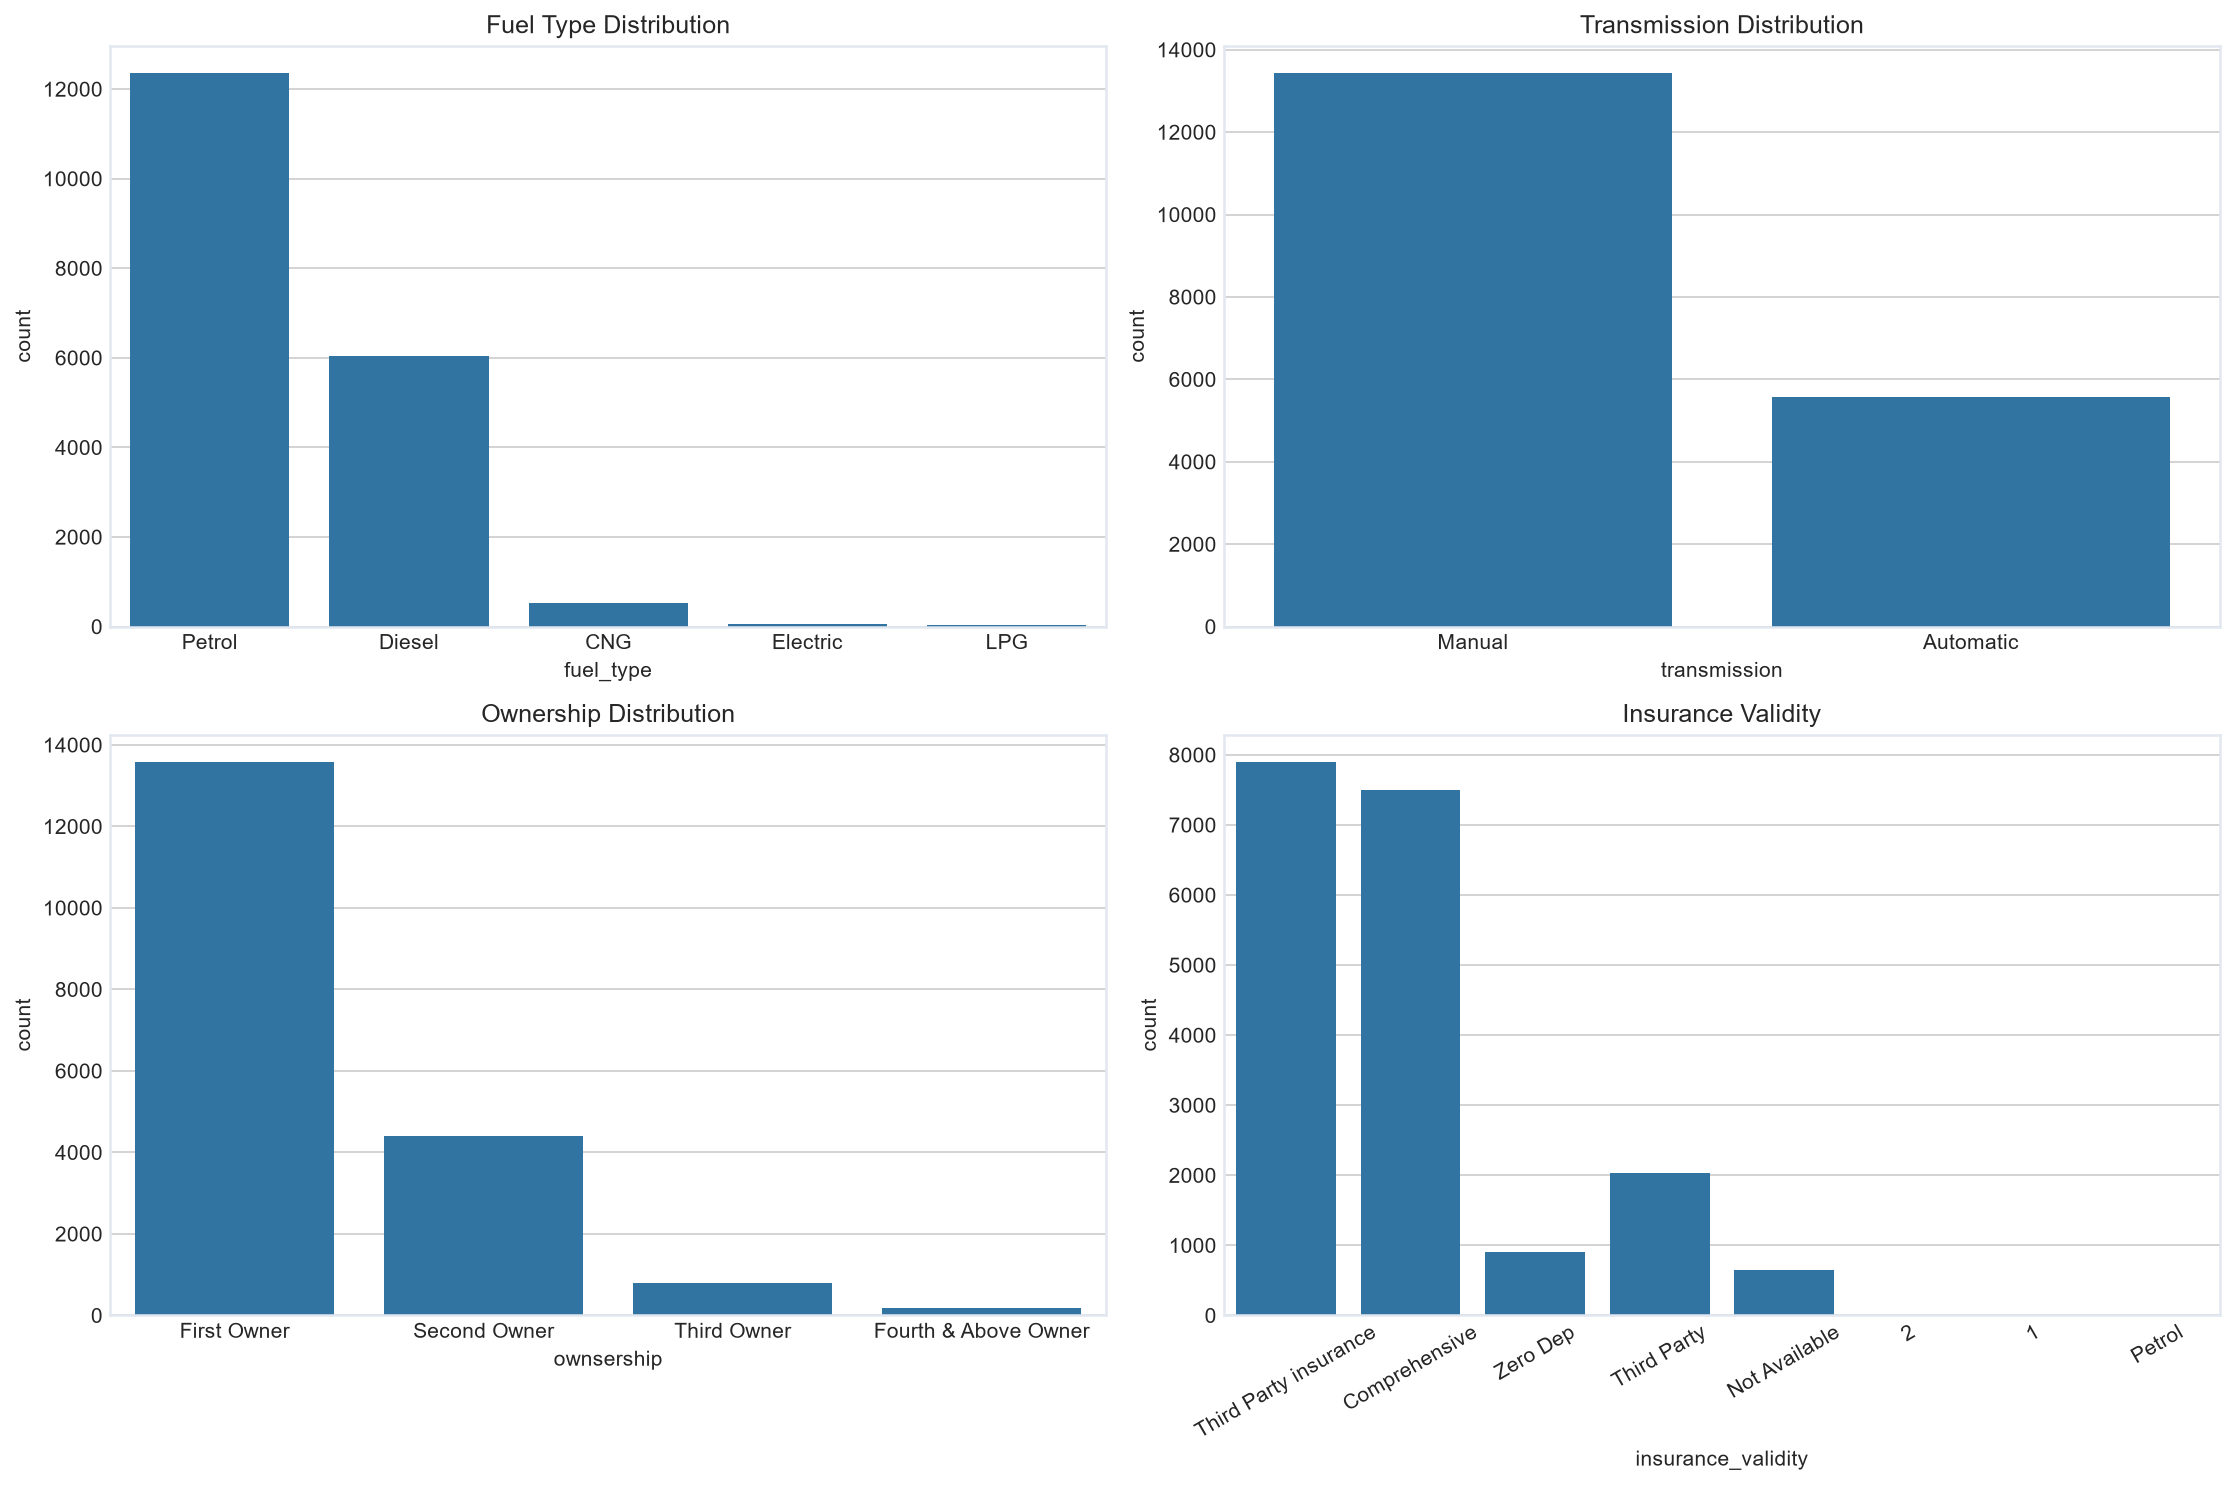

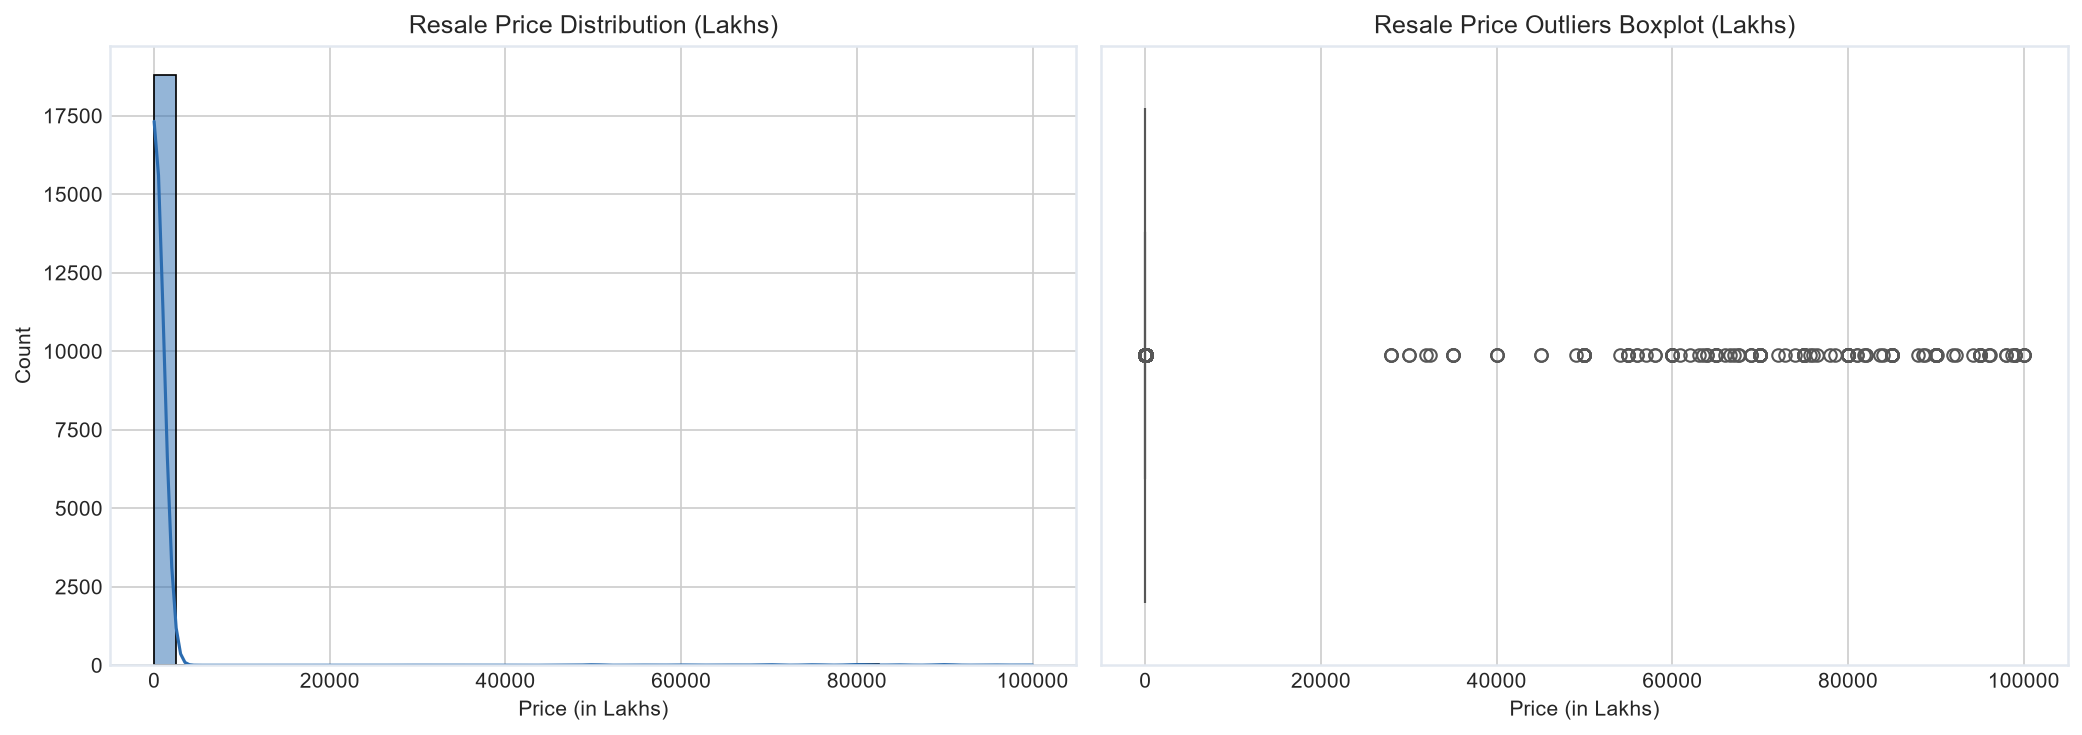

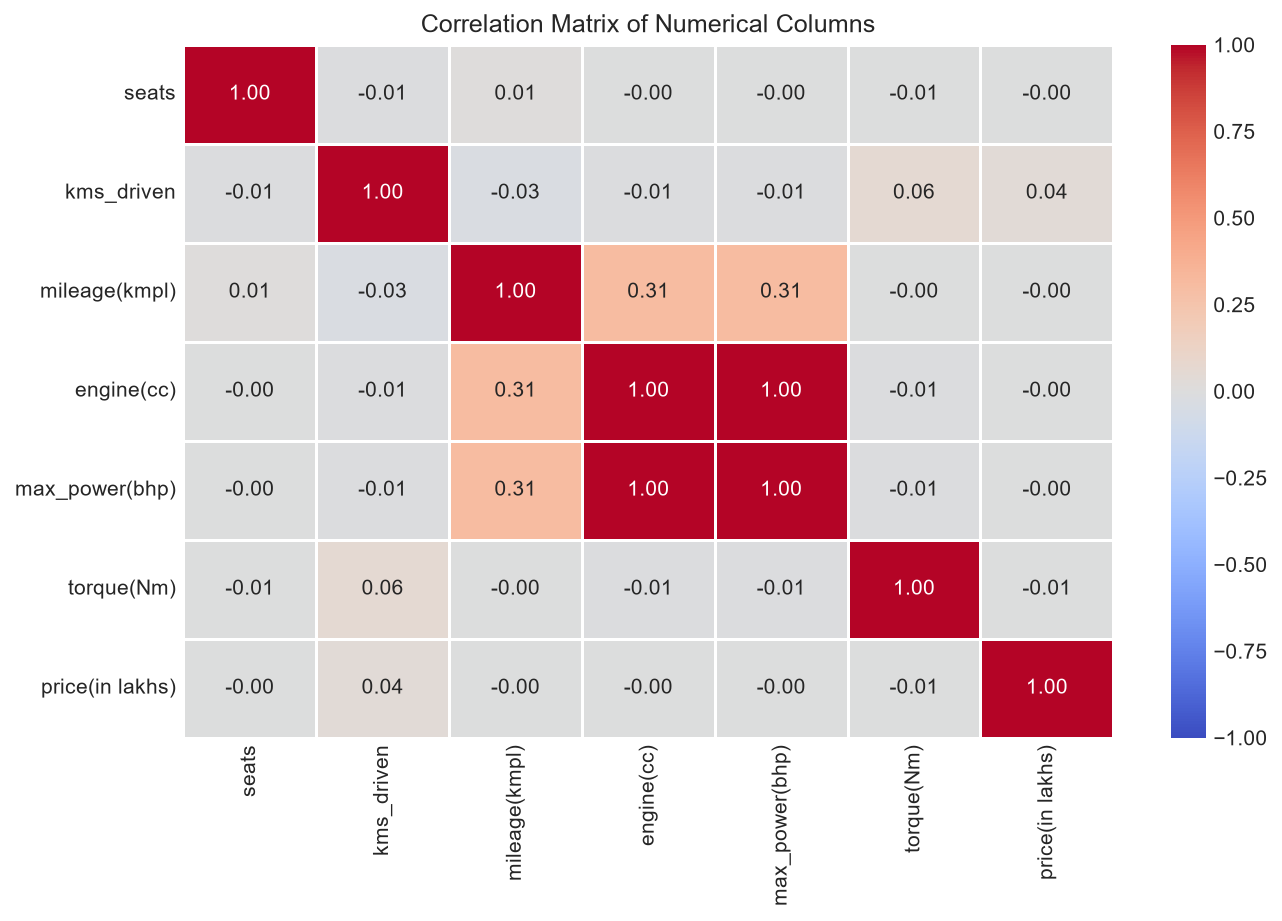

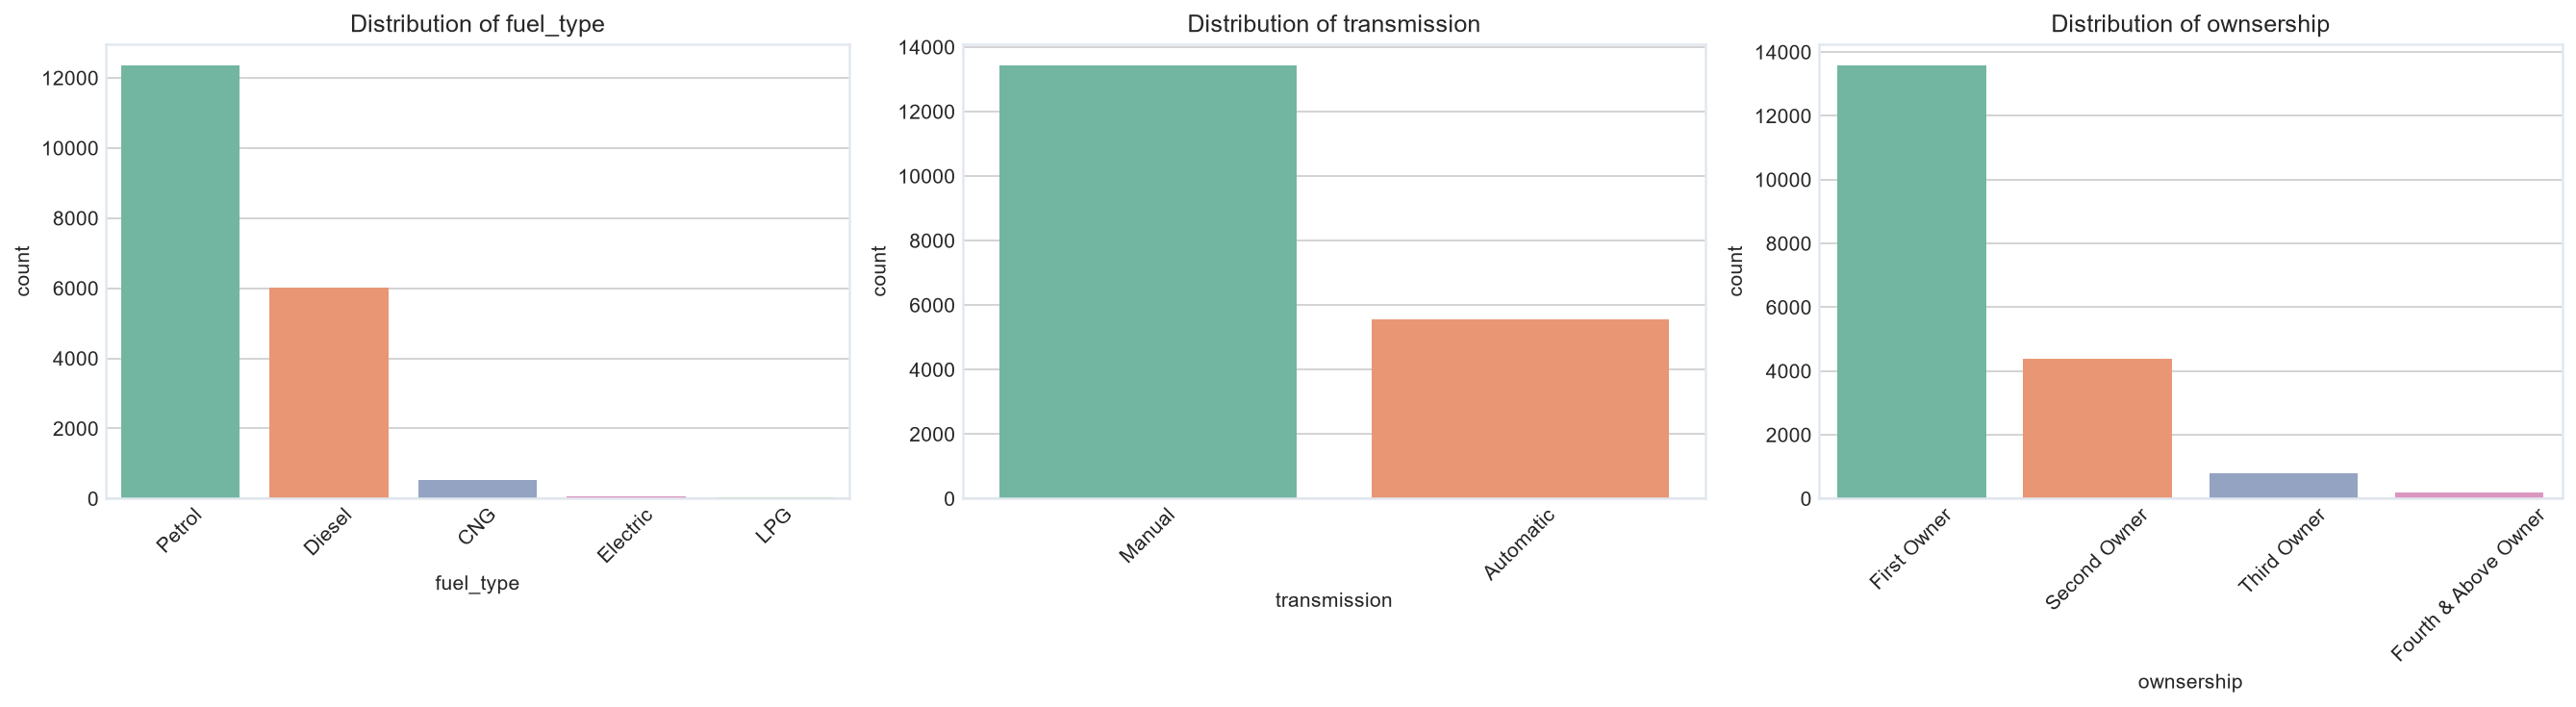

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# Fuel Type
sns.countplot(data=df, x="fuel_type", ax=axes[0,0])
axes[0,0].set_title("Fuel Type Distribution")

# Transmission
sns.countplot(data=df, x="transmission", ax=axes[0,1])
axes[0,1].set_title("Transmission Distribution")

# Ownership
sns.countplot(data=df, x="ownsership", ax=axes[1,0])
axes[1,0].set_title("Ownership Distribution")

# Insurance
sns.countplot(data=df, x="insurance_validity", ax=axes[1,1])
axes[1,1].tick_params(axis="x", rotation=30)
axes[1,1].set_title("Insurance Validity")

plt.tight_layout()
plt.show()

# 2. Target Variable Price Distribution (Histogram & Boxplot side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['price(in lakhs)'].dropna(), bins=40, kde=True, ax=axes[0], color='#2B6CB0')
axes[0].set_title('Resale Price Distribution (Lakhs)')
axes[0].set_xlabel('Price (in Lakhs)')

sns.boxplot(x=df['price(in lakhs)'].dropna(), ax=axes[1], color='#4299E1')
axes[1].set_title('Resale Price Outliers Boxplot (Lakhs)')
axes[1].set_xlabel('Price (in Lakhs)')
plt.tight_layout()
plt.show()

# 3. Numerical Correlation Heatmap
plt.figure(figsize=(10, 6))
numerical_cols_only = df.select_dtypes(include=[np.number])
if 'Unnamed: 0' in numerical_cols_only.columns:
    numerical_cols_only = numerical_cols_only.drop(columns=['Unnamed: 0'])
corr = numerical_cols_only.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

# 4. Categorical Feature Distributions
cat_features = ['fuel_type', 'transmission', 'ownsership']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(cat_features):
    if col in df.columns:
        sns.countplot(data=df, x=col, ax=axes[idx], palette='Set2')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Data Cleaning

We implement robust data cleaning policies:
1. **Datatype Coercion**: Force numeric columns to numeric datatypes, mapping invalid representations to `NaN`.
2. **Impossible Value Detection**: Map logically impossible configurations (e.g. registration/manufacturing year in future or before 1980, manufacturing year after registration, negative odometer, zero seats) to `NaN` rather than dropping the entire row. 
3. **Deduplication**: Run subset-based duplicate removal to preserve dataset validity.
4. **Outlier Capping**: Handled statistical outliers on input features using IQR capping with a configurable multiplier, keeping target variable `price(in lakhs)` uncapped to preserve luxury car signals.

In [4]:
df_clean = df.copy()

# Drop original index column if present
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Unnamed: 0'])

# 1. Datatype Coercion
numeric_cols_to_coerce = [
    'registration_year', 'manufacturing_year', 'kms_driven', 
    'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)', 'price(in lakhs)', 'seats'
]

for col in numeric_cols_to_coerce:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 2. Impossible Value Detection (set to NaN instead of dropping rows)
current_year = datetime.now().year

# Years sanity checks
df_clean.loc[(df_clean['registration_year'] < 1980) | (df_clean['registration_year'] > current_year), 'registration_year'] = np.nan
df_clean.loc[(df_clean['manufacturing_year'] < 1980) | (df_clean['manufacturing_year'] > current_year), 'manufacturing_year'] = np.nan
df_clean.loc[df_clean['manufacturing_year'] > df_clean['registration_year'], 'manufacturing_year'] = np.nan

# Physical columns sanity checks
df_clean.loc[df_clean['kms_driven'] < 0, 'kms_driven'] = np.nan
df_clean.loc[df_clean['kms_driven'] > 1500000, 'kms_driven'] = np.nan # Configurable upper limit for sanity
df_clean.loc[df_clean['engine(cc)'] < 50, 'engine(cc)'] = np.nan
df_clean.loc[df_clean['max_power(bhp)'] <= 0, 'max_power(bhp)'] = np.nan
df_clean.loc[df_clean['torque(Nm)'] <= 0, 'torque(Nm)'] = np.nan
df_clean.loc[df_clean['price(in lakhs)'] <= 0, 'price(in lakhs)'] = np.nan
df_clean.loc[(df_clean['seats'] <= 0) | (df_clean['seats'] > 12), 'seats'] = np.nan

# Record counts of impossible values caught
impossible_counts = df.shape[0] - df_clean.notnull().all(axis=1).sum()

# 3. Statistical Outlier Capping on INPUT Features using IQR (Do NOT cap the target 'price(in lakhs)')
features_to_cap = ['kms_driven', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)']
iqr_multiplier = 3.0 # Configurable multiplier to allow extreme valid luxury vehicles
capped_count = 0

for col in features_to_cap:
    if col in df_clean.columns:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - (iqr_multiplier * iqr)
        upper_bound = q3 + (iqr_multiplier * iqr)
        
        # Cap values instead of dropping
        original_vals = df_clean[col].copy()
        df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)
        capped_count += (original_vals != df_clean[col]).sum()

# 4. Duplicate Handling using a meaningful subset of identifiers
duplicate_subset = ['car_name', 'registration_year', 'kms_driven', 'fuel_type', 'transmission', 'price(in lakhs)']
df_clean = df_clean.drop_duplicates(subset=duplicate_subset)

print(f"Cleaned dataset size: {df_clean.shape}")
print(f"Impossible values flagged/set to NaN: {impossible_counts}")
print(f"Statistical outlier inputs capped: {capped_count}")

Cleaned dataset size: (18306, 14)
Impossible values flagged/set to NaN: 18904
Statistical outlier inputs capped: 21383


## 5. Feature Engineering

We construct robust representation features from the cleaned columns:
1. **Make & Model Parser**: Map brands using a prioritized list of multi-word manufacturers. For unmatched names, we preserve the first word rather than replacing with an 'Other' token.
2. **Age**: Calculate `car_age` using `registration_year` with a fallback to `manufacturing_year` if NaN (clamped to a minimum age of 1).
3. **Milage Ratio**: Calculate `kms_per_year` (safe against zero age).
4. **Luxury Identifier**: Create a binary `is_luxury_brand` classification.
5. **Experimental Features**: Ratios like `engine_per_seat`, `power_per_cc`, and `torque_per_cc` are added for evaluation.

In [5]:
KNOWN_BRANDS = [
    "Maruti Suzuki", "Mercedes-Benz", "Land Rover", "Rolls Royce",
    "Aston Martin", "Alfa Romeo", "Force Motors", "MG", "BMW",
    "Audi", "Volkswagen", "Toyota", "Honda", "Hyundai", "Kia",
    "Tata", "Mahindra", "Nissan", "Ford", "Renault", "Skoda",
    "Jeep", "Volvo", "Porsche", "Jaguar", "Lexus", "Mini",
    "Mitsubishi", "Fiat", "Datsun", "Citroen", "BYD", "Isuzu"
]

# Always match the longest brand name first
KNOWN_BRANDS = sorted(KNOWN_BRANDS, key=len, reverse=True)

def parse_make_model(row):
    car_name = str(row['car_name']).strip()
    # Strip leading 4-digit year if present
    car_name_clean = re.sub(r'^\d{4}\s+', '', car_name)
    
    matched_brand = None
    for brand in KNOWN_BRANDS:
        if car_name_clean.lower().startswith(brand.lower()):
            matched_brand = brand
            break
            
    if matched_brand:
        make = matched_brand
        remaining = car_name_clean[len(matched_brand):].strip()
    else:
        # Preserve the original manufacturer string first word if no match
        parts = car_name_clean.split()
        make = parts[0] if parts else "Unknown"
        remaining = " ".join(parts[1:]) if len(parts) > 1 else ""
        
    model_parts = remaining.split()
    model = model_parts[0] if model_parts else "Unknown"
    return pd.Series([make, model])

## Apply parsing
df_clean[['make', 'model']] = df_clean.apply(parse_make_model, axis=1)

# Drop raw car_name
df_clean = df_clean.drop(columns=['car_name'])

print("Successfully parsed make/model.")

Successfully parsed make/model.


## 6. Preprocessing & Train-Test Split

We construct our features $X$ and target $y$ (`price(in lakhs)`), split the dataset to preserve reproducibility, and implement a data leakage check.

In [6]:
# ----------------------------------------------------
# Remove corrupted target values
# ----------------------------------------------------
df_clean = df_clean[
    (df_clean["price(in lakhs)"] >= 0.5) &
    (df_clean["price(in lakhs)"] <= 500)
].copy()

print("Dataset shape after removing invalid target values:", df_clean.shape)

# Defining target variable and input features
target_col = "price(in lakhs)"

training_features = [
    "make",
    "model",
    "registration_year",
    "fuel_type",
    "transmission",
    "ownsership",
    "kms_driven",
    "seats",
    "mileage(kmpl)",
    "engine(cc)",
]

training_dataset = df_clean.copy()
training_dataset.to_csv(PROCESSED_DATASET_PATH, index=False)
print(f"Saved processed training dataset to: {PROCESSED_DATASET_PATH}")

X = training_dataset[training_features].copy()
y = training_dataset[target_col].copy()

# Data Leakage Verification
assert target_col not in X.columns, \
    f"{target_col} found in training features."

print("✅ Target column is excluded from X.")

# Optional sanity check
assert len(X) == len(y)

print("✅ Feature matrix and target have matching row counts.")

# Train-Test Split (fixed seed for reproducibility)

# Train-Test Split (fixed seed for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Dataset shape after removing invalid target values: (18107, 15)
Saved processed training dataset to: ../data/processed\processed_training_dataset.csv
✅ Target column is excluded from X.
✅ Feature matrix and target have matching row counts.
Train set shape: (14485, 10)
Test set shape: (3622, 10)


## 7. Preprocessing ColumnTransformer Setup

We construct two preprocessing transformers:
- Scale-free preprocessing for Tree-based models (RandomForest, GBM, XGBoost, CatBoost) to preserve split logic.
- Scaled preprocessing (with SimpleImputer and RobustScaler/StandardScaler depending on `SCALER_TYPE`) for Linear Regression to handle extreme values properly.

In [7]:
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

chosen_scaler = RobustScaler() if SCALER_TYPE == 'RobustScaler' else StandardScaler()
print(f"Applying {SCALER_TYPE} to linear model pipeline.")

# 1. Scaled pipeline (for scale-sensitive models like LinearRegression)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', chosen_scaler)
        ]), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ]
)

# 2. Scale-free pipeline (for tree-based models where scaling is not meaningful)
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ]
)

print("Preprocessing pipelines constructed (Scaled and Scale-Free variants).")

Applying RobustScaler to linear model pipeline.
Preprocessing pipelines constructed (Scaled and Scale-Free variants).


## 8. MLflow Experiment Configurations

We register the MLflow local or server-based tracking URI and initialize the experiment.

In [8]:
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

TRACKING_URI = "http://127.0.0.1:5000"
LOCAL_TRACKING_URI = "file:../mlruns"

parsed = urlparse(TRACKING_URI)
host = parsed.hostname or "127.0.0.1"
port = parsed.port or 5000

server_active = False

try:
    with socket.create_connection((host, port), timeout=2):
        server_active = True
except OSError:
    server_active = False

if server_active:
    mlflow.set_tracking_uri(TRACKING_URI)
    print(f"✅ Connected to MLflow Tracking Server")
    print(f"Tracking URI : {TRACKING_URI}")
    print(f"MLflow UI    : {TRACKING_URI}")
else:
    mlflow.set_tracking_uri(LOCAL_TRACKING_URI)
    print("⚠ MLflow Tracking Server not running.")
    print(f"Using local file store: {LOCAL_TRACKING_URI}")

EXPERIMENT_NAME = "Carlytics_Vehicle_Valuation"

mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Experiment Name : {EXPERIMENT_NAME}")
print(f"Effective URI   : {mlflow.get_tracking_uri()}")

✅ Connected to MLflow Tracking Server
Tracking URI : http://127.0.0.1:5000
MLflow UI    : http://127.0.0.1:5000


2026/07/27 22:14:29 INFO mlflow.tracking.fluent: Experiment with name 'Carlytics_Vehicle_Valuation' does not exist. Creating a new experiment.


Experiment Name : Carlytics_Vehicle_Valuation
Effective URI   : http://127.0.0.1:5000


## 9. Data Quality Report & Model Training

We output the **Data Quality Checkpoint** summarizing datasets, imputations, and feature dimensions. Then, we tune hyperparameters for 5 candidates (LinearRegression, RandomForest, GradientBoosting, XGBoost, CatBoost) using 5-Fold `RandomizedSearchCV`.

In [9]:
print("============================================================")
print("  CARLYTICS — DATA QUALITY REPORT")
print("============================================================")
print(f"  Initial row count        : {df.shape[0]}")
print(f"  Final row count          : {df_clean.shape[0]}")
print(f"  Duplicates rows removed  : {duplicates_count}")
print(f"  Impossible values flagged: {impossible_counts}")
print(f"  Outliers capped (IQR)    : {capped_count}")
print(f"  Numerical columns        : {len(numerical_cols)}")
print(f"  Categorical columns      : {len(categorical_cols)}")
print(f"  Target column            : {target_col}")
print(f"  Train Set Rows           : {X_train.shape[0]}")
print(f"  Test Set Rows            : {X_test.shape[0]}")
print("============================================================")

# Benchmarking models with RandomizedSearchCV configurations
models_config = {

    "LinearRegression": (
        LinearRegression(),
        {
            "regressor__fit_intercept": [True, False]
        },
        preprocessor_scaled,
        2
    ),

    "Ridge": (
        Ridge(random_state=42),
        {
            "regressor__alpha": [0.1, 1, 10, 100]
        },
        preprocessor_scaled,
        8
    ),

    "Lasso": (
        Lasso(random_state=42, max_iter=10000),
        {
            "regressor__alpha": [0.001, 0.01, 0.1, 1]
        },
        preprocessor_scaled,
        8
    ),

    "DecisionTree": (
        DecisionTreeRegressor(random_state=42),
        {
            "regressor__max_depth": [5, 10, 20, None],
            "regressor__min_samples_split": [2, 5, 10],
            "regressor__min_samples_leaf": [1, 2, 4]
        },
        preprocessor_unscaled,
        10
    ),

    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {
            "regressor__n_estimators": [100, 200, 300],
            "regressor__max_depth": [10, 20, 30, None],
            "regressor__min_samples_split": [2, 5, 10],
            "regressor__min_samples_leaf": [1, 2, 4]
        },
        preprocessor_unscaled,
        10
    ),

    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {
            "regressor__n_estimators": [100, 200, 300, 500],
            "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "regressor__max_depth": [2, 3, 4, 5],
            "regressor__subsample": [0.8, 0.9, 1.0],
            "regressor__min_samples_split": [2, 5],
            "regressor__min_samples_leaf": [1, 2]
        },
        preprocessor_unscaled,
        8
    ),

    "XGBoost": (
        XGBRegressor(random_state=42, verbosity=0),
        {
            "regressor__n_estimators": [100, 200],
            "regressor__learning_rate": [0.05, 0.1, 0.15],
            "regressor__max_depth": [3, 5]
        },
        preprocessor_unscaled,
        20
    ),

    "CatBoost": (
        CatBoostRegressor(random_state=42, verbose=0),
        {
            "regressor__iterations": [100, 200],
            "regressor__learning_rate": [0.05, 0.1, 0.15],
            "regressor__depth": [4, 6]
        },
        preprocessor_unscaled,
        8
    ),

    "SVR": (
        SVR(),
        {
            "regressor__C": [1, 10, 100],
            "regressor__gamma": ["scale", "auto"],
            "regressor__kernel": ["rbf"]
        },
        preprocessor_scaled,
        8
    )
}

runs_info = []

for model_name, (model, param_dist, preprocessor_variant, n_iter) in models_config.items():
    try:
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor_variant),
            ('regressor', model)
        ])
        
        with mlflow.start_run(run_name=model_name) as run:
            print(f"\n--- Tuning & Running {model_name} ---")
            
            random_search = RandomizedSearchCV(
                estimator=pipeline, 
                param_distributions=param_dist, 
                n_iter=n_iter,
                cv=5, 
                n_jobs=-1, 
                scoring='neg_mean_absolute_error', 
                random_state=42,
                verbose=0
            )
            random_search.fit(X_train, y_train)
            best_pipeline_model = random_search.best_estimator_
            
            # Log parameters
            for param, value in random_search.best_params_.items():
                mlflow.log_param(param, value)
                
            # Predict
            y_pred = best_pipeline_model.predict(X_test)
            
            # Metrics
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            mape = mean_absolute_percentage_error(y_test, y_pred)
            
            mlflow.log_metric("mae", mae)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("r2_score", r2)
            mlflow.log_metric("mape", mape)
            
            report_text = (
                f"Regression Performance Report\n"
                f"Model Name: {model_name}\n"
                f"MAE: {mae:.4f} Lakhs\n"
                f"RMSE: {rmse:.4f} Lakhs\n"
                f"R2 Score: {r2:.4f}\n"
                f"MAPE: {mape:.4f}\n"
            )
            mlflow.log_text(report_text, "regression_report.txt")
            
            # Log Model
            sample_input = X_train.head(5)
            sample_output = best_pipeline_model.predict(sample_input)

            signature = infer_signature(
                sample_input,
                sample_output
            )

            mlflow.sklearn.log_model(
                sk_model=best_pipeline_model,
                artifact_path="model",
                signature=signature,
                input_example=X_train.head(2),
                serialization_format="pickle"
            )
            
            run_id = run.info.run_id
            experiment_id = run.info.experiment_id

            if server_active:
                print("\n========================================")
                print(f"🏃 Run URL:")
                print(f"{TRACKING_URI}/#/experiments/{experiment_id}/runs/{run_id}")
                print()
                print("🧪 Experiment URL:")
                print(f"{TRACKING_URI}/#/experiments/{experiment_id}")
                print("========================================\n")
        
            print("=" * 70)
            print(f"Model        : {model_name}")
            print(f"Best Params  : {random_search.best_params_}")
            print(f"MAE          : {mae:.4f} Lakhs")
            print(f"RMSE         : {rmse:.4f} Lakhs")
            print(f"R² Score     : {r2:.4f}")
            print(f"MAPE         : {mape*100:.2f}%")
            print("=" * 70)
            
            runs_info.append({
                "Model": model_name,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2,
                "MAPE": mape,
                "Pipeline": best_pipeline_model,
                "Params": random_search.best_params_,
                "Run_ID": run.info.run_id
            })
            
            mlflow.set_tag("Model", model_name)
            mlflow.set_tag("Framework", "scikit-learn")
            mlflow.set_tag("Project", "Carlytics")
            mlflow.set_tag("Dataset", "Final Dataset")
            
    except Exception as e:
        print(f"Error running {model_name}: {e}")

  CARLYTICS — DATA QUALITY REPORT
  Initial row count        : 18999
  Final row count          : 18107
  Duplicates rows removed  : 636
  Impossible values flagged: 18904
  Outliers capped (IQR)    : 21383
  Numerical columns        : 5
  Categorical columns      : 5
  Target column            : price(in lakhs)
  Train Set Rows           : 14485
  Test Set Rows            : 3622

--- Tuning & Running LinearRegression ---


2026/07/27 22:14:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 22:14:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/27 22:14:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



🏃 Run URL:
http://127.0.0.1:5000/#/experiments/1/runs/a5e1a74ae5c149b2963064afeeb36383

🧪 Experiment URL:
http://127.0.0.1:5000/#/experiments/1

Model        : LinearRegression
Best Params  : {'regressor__fit_intercept': True}
MAE          : 2.4695 Lakhs
RMSE         : 5.2633 Lakhs
R² Score     : 0.7298
MAPE         : 40.99%
🏃 View run LinearRegression at: http://127.0.0.1:5000/#/experiments/1/runs/a5e1a74ae5c149b2963064afeeb36383
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

--- Tuning & Running Ridge ---


2026/07/27 22:14:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 22:14:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/27 22:14:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



🏃 Run URL:
http://127.0.0.1:5000/#/experiments/1/runs/305b5ce769134172b6bdbb2d45e4db59

🧪 Experiment URL:
http://127.0.0.1:5000/#/experiments/1

Model        : Ridge
Best Params  : {'regressor__alpha': 0.1}
MAE          : 2.4703 Lakhs
RMSE         : 5.2403 Lakhs
R² Score     : 0.7322
MAPE         : 41.07%
🏃 View run Ridge at: http://127.0.0.1:5000/#/experiments/1/runs/305b5ce769134172b6bdbb2d45e4db59
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

--- Tuning & Running Lasso ---


...


🏃 Run URL:
http://127.0.0.1:5000/#/experiments/1/runs/335e2bd69a1c4a1bb259e6498a3ec9f0

🧪 Experiment URL:
http://127.0.0.1:5000/#/experiments/1

Model        : XGBoost
Best Params  : {'regressor__n_estimators': 200, 'regressor__max_depth': 5, 'regressor__learning_rate': 0.15}
MAE          : 1.8664 Lakhs
RMSE         : 3.9185 Lakhs
R² Score     : 0.8502
MAPE         : 29.26%
🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/335e2bd69a1c4a1bb259e6498a3ec9f0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

--- Tuning & Running CatBoost ---


2026/07/27 22:28:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 22:28:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/27 22:28:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



🏃 Run URL:
http://127.0.0.1:5000/#/experiments/1/runs/104a7625a8af435d8e567b7cd5377ac9

🧪 Experiment URL:
http://127.0.0.1:5000/#/experiments/1

Model        : CatBoost
Best Params  : {'regressor__learning_rate': 0.15, 'regressor__iterations': 200, 'regressor__depth': 6}
MAE          : 2.0682 Lakhs
RMSE         : 4.0445 Lakhs
R² Score     : 0.8404
MAPE         : 33.03%
🏃 View run CatBoost at: http://127.0.0.1:5000/#/experiments/1/runs/104a7625a8af435d8e567b7cd5377ac9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

--- Tuning & Running SVR ---


2026/07/27 22:36:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 22:36:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/27 22:36:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



🏃 Run URL:
http://127.0.0.1:5000/#/experiments/1/runs/031988b5f0484abd9a8e7d8cb3278550

🧪 Experiment URL:
http://127.0.0.1:5000/#/experiments/1

Model        : SVR
Best Params  : {'regressor__kernel': 'rbf', 'regressor__gamma': 'scale', 'regressor__C': 100}
MAE          : 1.6272 Lakhs
RMSE         : 3.8908 Lakhs
R² Score     : 0.8523
MAPE         : 24.32%
🏃 View run SVR at: http://127.0.0.1:5000/#/experiments/1/runs/031988b5f0484abd9a8e7d8cb3278550
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## 10. Model Leaderboard & Evaluation

We construct an evaluation table, identify the best performing model based on MAE, plot its residuals, actual vs predicted values, and cross-validation scores.

=== MODEL PERFORMANCE LEADERBOARD ===


,Rank,Model,MAE,RMSE,R2,MAPE,R2_Accuracy_Percentage
0,1,SVR,1.6272 Lakhs,3.8908 Lakhs,0.852347,0.24%,85.23%
1,2,RandomForest,1.7165 Lakhs,4.0610 Lakhs,0.839146,0.26%,83.91%
2,3,XGBoost,1.8664 Lakhs,3.9185 Lakhs,0.850234,0.29%,85.02%
3,4,GradientBoosting,2.0074 Lakhs,4.2702 Lakhs,0.822146,0.32%,82.21%
4,5,CatBoost,2.0682 Lakhs,4.0445 Lakhs,0.840450,0.33%,84.04%
5,6,DecisionTree,2.0730 Lakhs,5.0844 Lakhs,0.747862,0.30%,74.79%
6,7,LinearRegression,2.4695 Lakhs,5.2633 Lakhs,0.729805,0.41%,72.98%
7,8,Ridge,2.4703 Lakhs,5.2403 Lakhs,0.732155,0.41%,73.22%
8,9,Lasso,2.5333 Lakhs,5.2291 Lakhs,0.733303,0.42%,73.33%



Successfully selected SVR as the best model for Carlytics.
Params: {'regressor__kernel': 'rbf', 'regressor__gamma': 'scale', 'regressor__C': 100}


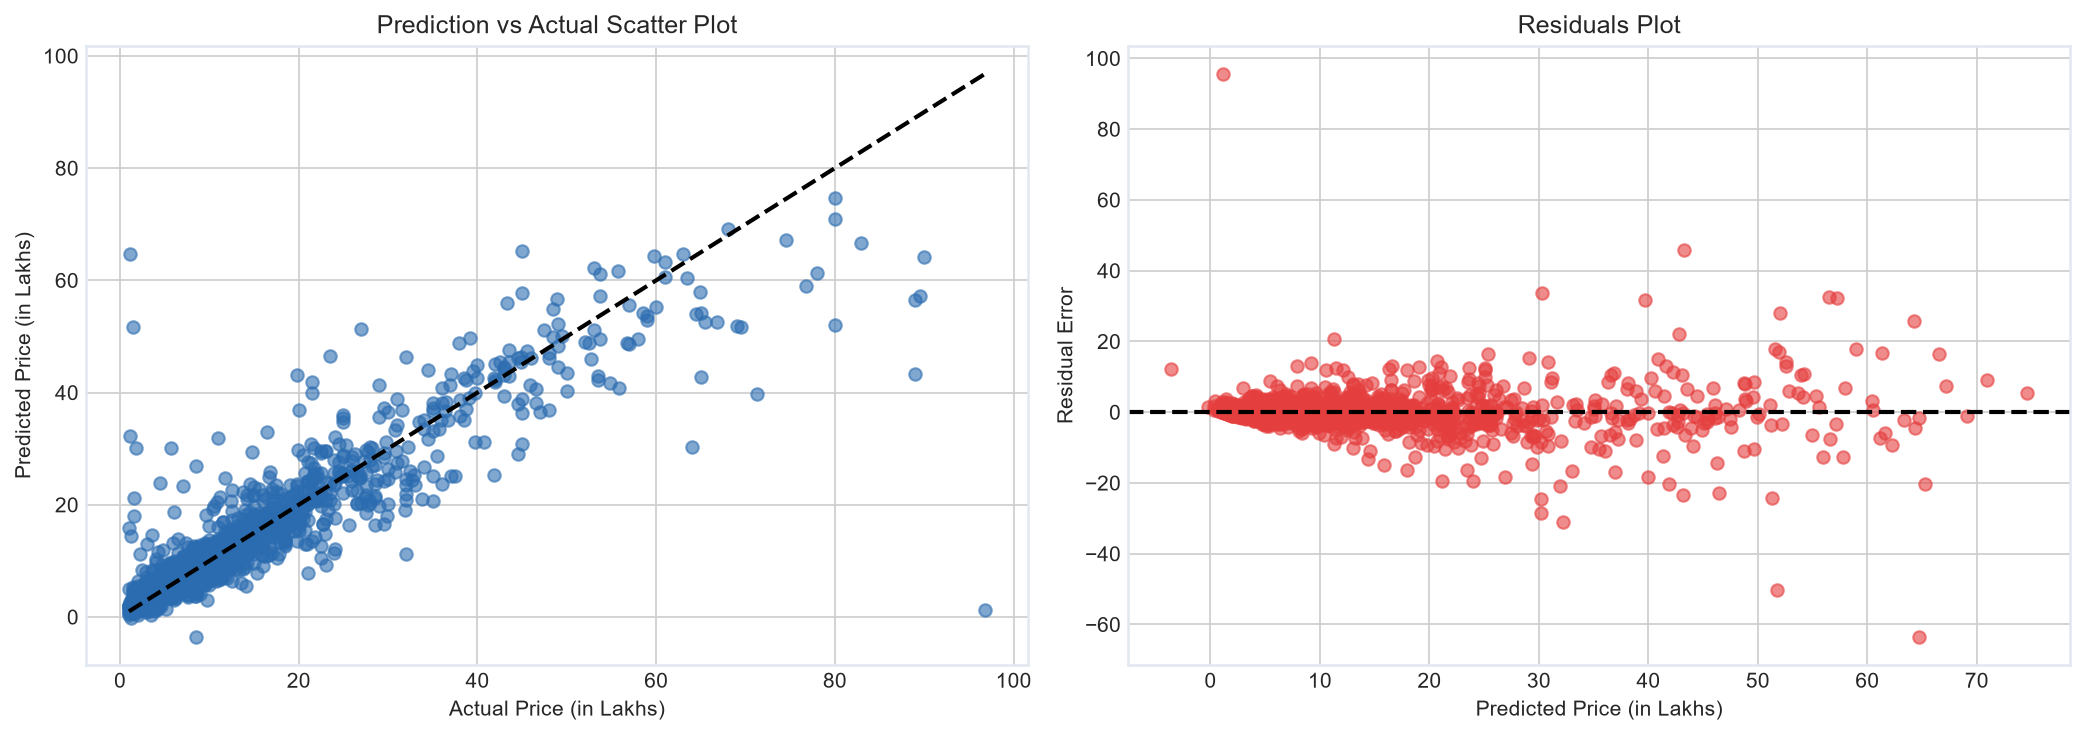


--- 5-Fold Cross Validation ---
CV MAE: 1.8098 Lakhs (± 0.0518 Lakhs)


In [10]:
results_df = pd.DataFrame(runs_info).sort_values(by="MAE").reset_index(drop=True)
results_df['R2_Accuracy_Percentage'] = results_df['R2'] * 100.0
results_df.insert(0, 'Rank', range(1, len(results_df) + 1))

display_df = results_df[['Rank', 'Model', 'MAE', 'RMSE', 'R2', 'MAPE', 'R2_Accuracy_Percentage']].copy()
display_df['MAE'] = display_df['MAE'].map('{:.4f} Lakhs'.format)
display_df['RMSE'] = display_df['RMSE'].map('{:.4f} Lakhs'.format)
display_df['MAPE'] = display_df['MAPE'].map('{:.2f}%'.format)
display_df['R2_Accuracy_Percentage'] = display_df['R2_Accuracy_Percentage'].map('{:.2f}%'.format)

print("=== MODEL PERFORMANCE LEADERBOARD ===")
display(display_df)

best_run = results_df.iloc[0]
best_pipeline = best_run["Pipeline"]
best_model_name = best_run["Model"]
best_model_params = best_run["Params"]
best_run_id = best_run["Run_ID"]

print(f"\nSuccessfully selected {best_model_name} as the best model for Carlytics.")
print(f"Params: {best_model_params}")

# 1. Prediction vs Actual Scatter Plot & Residual Plot
y_pred_best = best_pipeline.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_best, alpha=0.6, color='#2B6CB0')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_title('Prediction vs Actual Scatter Plot')
axes[0].set_xlabel('Actual Price (in Lakhs)')
axes[0].set_ylabel('Predicted Price (in Lakhs)')

axes[1].scatter(y_pred_best, residuals, alpha=0.6, color='#E53E3E')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals Plot')
axes[1].set_xlabel('Predicted Price (in Lakhs)')
axes[1].set_ylabel('Residual Error')
plt.tight_layout()
plt.show()

# 2. Cross-Validation Score of the Best Model (5-fold)
print("\n--- 5-Fold Cross Validation ---")
cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
mean_cv_mae = -cv_scores.mean()
std_cv_mae = cv_scores.std()
print(f"CV MAE: {mean_cv_mae:.4f} Lakhs (± {std_cv_mae:.4f} Lakhs)")

# 3. Feature Importance & Underperforming Feature Identification (Only for Tree-based best models)
regressor_model = best_pipeline.named_steps['regressor']
if hasattr(regressor_model, 'feature_importances_'):
    # We extract feature names from the OneHotEncoder step
    ohe_step = best_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
    cat_features_transformed = ohe_step.get_feature_names_out(categorical_cols)
    feature_names = np.concatenate([numerical_cols, cat_features_transformed])
    
    importances = regressor_model.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    print("\n===============================")
    print("Feature Importance Summary")
    print("===============================")
    for idx, row in importance_df.iterrows():
        print(f"{row['Feature']:<30} {row['Importance']:.4f}")
    
        print("===============================")
    print("Feature importance computed successfully.")
    print("This model is trained using the selected raw input features only.")


## 11. Model Explainability

,Feature,Importance
0,make,2.634735
9,engine(cc),2.532722
1,model,1.805035
8,mileage(kmpl),1.032524
6,kms_driven,0.689674
3,fuel_type,0.618182
2,registration_year,0.598638
4,transmission,0.448278
7,seats,0.304381
5,ownsership,0.104801


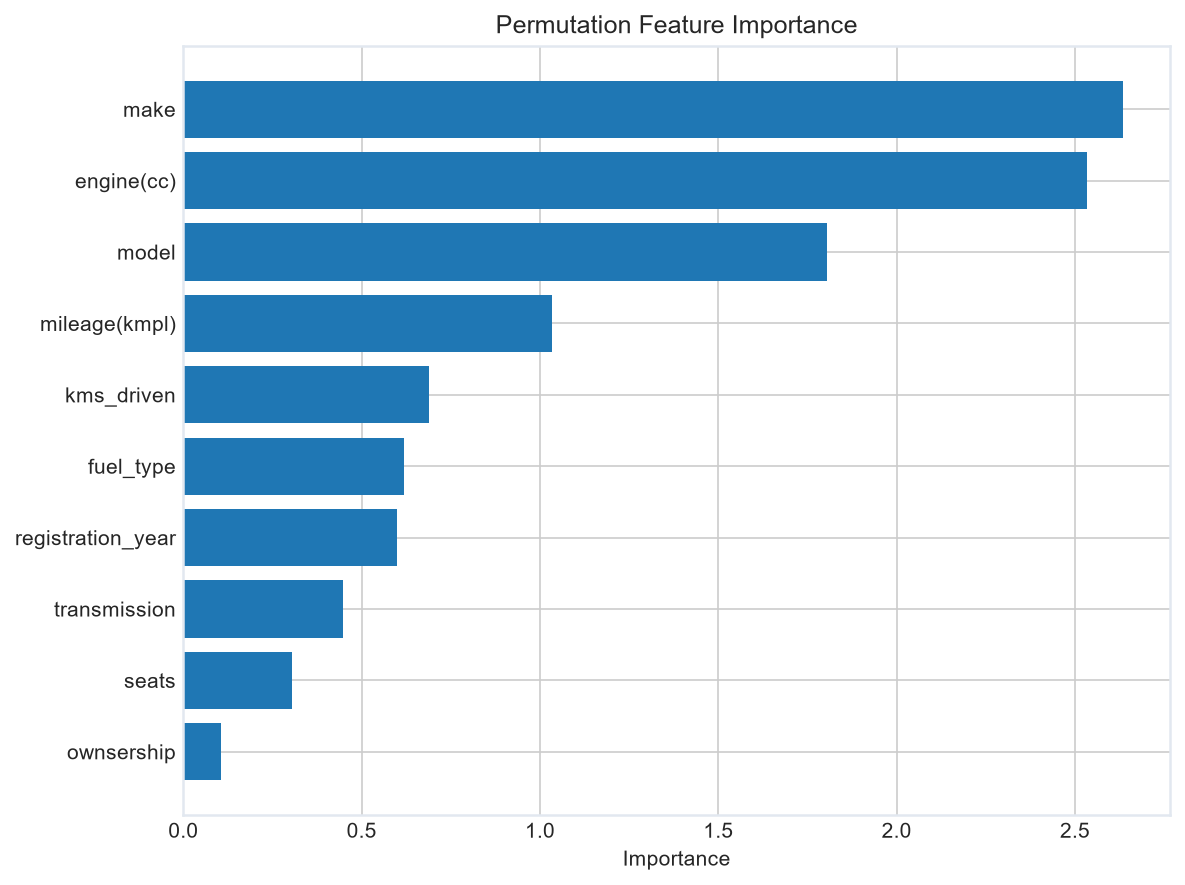

In [11]:
result = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 12. Pipeline Edge Case Robustness Testing

We construct various edge case scenarios (unseen categories, extreme value parameters, NaNs) and run predictions directly through our fitted pipeline to guarantee inference stability.

In [12]:
robustness_test_cases = [
    {
        "name": "Unseen Manufacturer",
        "data": {
            "make": "AeroCar",
            "model": "Swift",
            "registration_year": 2018,
            "fuel_type": "Petrol",
            "transmission": "Manual",
            "ownsership": "First Owner",
            "kms_driven": 45000.0,
            "seats": 5,
            "mileage(kmpl)": 18.9,
            "engine(cc)": 1197.0
        }
    },
    {
        "name": "Unseen Model",
        "data": {
            "make": "Maruti Suzuki",
            "model": "Phantom X",
            "registration_year": 2018,
            "fuel_type": "Petrol",
            "transmission": "Manual",
            "ownsership": "First Owner",
            "kms_driven": 45000.0,
            "seats": 5,
            "mileage(kmpl)": 18.9,
            "engine(cc)": 1197.0
        }
    },
    {
        "name": "Missing Numerical Inputs",
        "data": {
            "make": "Maruti Suzuki",
            "model": "Swift",
            "registration_year": 2018,
            "fuel_type": "Petrol",
            "transmission": "Manual",
            "ownsership": "First Owner",
            "kms_driven": np.nan,
            "seats": np.nan,
            "mileage(kmpl)": np.nan,
            "engine(cc)": np.nan
        }
    },
    {
        "name": "Unknown Transmission",
        "data": {
            "make": "Maruti Suzuki",
            "model": "Swift",
            "registration_year": 2018,
            "fuel_type": "Petrol",
            "transmission": "HyperShift",
            "ownsership": "First Owner",
            "kms_driven": 45000.0,
            "seats": 5,
            "mileage(kmpl)": 18.9,
            "engine(cc)": 1197.0
        }
    },
    {
        "name": "Electric Vehicle",
        "data": {
            "make": "BYD",
            "model": "Atto",
            "registration_year": 2024,
            "fuel_type": "Electric",
            "transmission": "Automatic",
            "ownsership": "First Owner",
            "kms_driven": 12000.0,
            "seats": 5,
            "mileage(kmpl)": np.nan,
            "engine(cc)": np.nan
        }
    },
    {
        "name": "Extreme High Mileage",
        "data": {
            "make": "Toyota",
            "model": "Innova",
            "registration_year": 2010,
            "fuel_type": "Diesel",
            "transmission": "Manual",
            "ownsership": "Second Owner",
            "kms_driven": 850000.0,
            "seats": 7,
            "mileage(kmpl)": 12.8,
            "engine(cc)": 2494.0
        }
    }
]

print("=== RUNNING PIPELINE ROBUSTNESS TESTS ===")

for tc in robustness_test_cases:
    test_df = pd.DataFrame([tc["data"]])

    try:
        pred = best_pipeline.predict(test_df)
        print(f"✅ {tc['name']}: PASSED (Predicted Price: {pred[0]:.2f} Lakhs)")
    except Exception as e:
        print(f"❌ {tc['name']}: FAILED! Reason: {e}")

=== RUNNING PIPELINE ROBUSTNESS TESTS ===
✅ Unseen Manufacturer: PASSED (Predicted Price: 9.88 Lakhs)
✅ Unseen Model: PASSED (Predicted Price: 11.10 Lakhs)
✅ Missing Numerical Inputs: PASSED (Predicted Price: 9.63 Lakhs)
✅ Unknown Transmission: PASSED (Predicted Price: 11.03 Lakhs)
✅ Electric Vehicle: PASSED (Predicted Price: 16.42 Lakhs)
✅ Extreme High Mileage: PASSED (Predicted Price: 10.47 Lakhs)


## 13. Model Saving

We export the fitted sklearn pipeline directly to `../trained_models/`. The full pipeline contains both the transformers and the model estimator, maintaining frontend inference compatibility.

In [13]:
os.makedirs(MODEL_EXPORT_DIR, exist_ok=True)

preprocessor = best_pipeline.named_steps["preprocessor"]

model = best_pipeline.named_steps["regressor"]

encoder = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
)

scaler = None

try:
    scaler = (
        preprocessor
        .named_transformers_["num"]
        .named_steps["scaler"]
    )
except Exception:
    scaler = None

joblib.dump(
    model,
    os.path.join(
        MODEL_EXPORT_DIR,
        "best_model.pkl"
    )
)

joblib.dump(
    preprocessor,
    os.path.join(
        MODEL_EXPORT_DIR,
        "preprocessor.pkl"
    )
)

joblib.dump(
    encoder,
    os.path.join(
        MODEL_EXPORT_DIR,
        "encoder.pkl"
    )
)

if scaler is not None:

    joblib.dump(
        scaler,
        os.path.join(
            MODEL_EXPORT_DIR,
            "scaler.pkl"
        )
    )

joblib.dump(
    best_pipeline,
    os.path.join(
        MODEL_EXPORT_DIR,
        "pipeline.pkl"
    )
)

metadata = {

    "model_name": best_model_name,

    "parameters": best_model_params,

    "features": training_features,

    "target": target_col

}

joblib.dump(
    metadata,
    os.path.join(
        MODEL_EXPORT_DIR,
        "metadata.pkl"
    )
)

print("Artifacts Exported Successfully")

Artifacts Exported Successfully


## 14. Make Prediction on a New Sample

We verify predictions on a new mock dataset sample using the serialized best model.

In [16]:
# Load model artifacts from the production artifact layout
best_model_path = os.path.join(MODEL_EXPORT_DIR, "best_model.pkl")
preprocessor_path = os.path.join(MODEL_EXPORT_DIR, "preprocessor.pkl")
encoder_path = os.path.join(MODEL_EXPORT_DIR, "encoder.pkl")
scaler_path = os.path.join(MODEL_EXPORT_DIR, "scaler.pkl")
metadata_path = os.path.join(MODEL_EXPORT_DIR, "metadata.pkl")

best_model_loaded = joblib.load(best_model_path)
preprocessor_loaded = joblib.load(preprocessor_path)
encoder_loaded = joblib.load(encoder_path)
scaler_loaded = None
if os.path.exists(scaler_path):
    scaler_loaded = joblib.load(scaler_path)

print("Loaded artifacts:")
print(" - best_model:", type(best_model_loaded))
print(" - preprocessor:", type(preprocessor_loaded))
print(" - encoder:", type(encoder_loaded))
print(" - scaler:", type(scaler_loaded) if scaler_loaded is not None else "None")

input_data = pd.DataFrame([{
    "make": "Maruti",
    "model": "Swift",
    "registration_year": 2018,
    "fuel_type": "Petrol",
    "transmission": "Manual",
    "ownsership": "First Owner",
    "kms_driven": 45000.0,
    "seats": 5,
    "mileage(kmpl)": 18.9,
    "engine(cc)": 1197.0,
}])

# Preprocess the raw input
processed_input = preprocessor_loaded.transform(input_data)

# Predict using the trained SVR model
prediction = best_model_loaded.predict(processed_input)

print(f"Predicted Used Car Resale Price: {prediction[0]:.2f} Lakhs")


Loaded artifacts:
 - best_model: <class 'sklearn.svm._classes.SVR'>
 - preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
 - encoder: <class 'sklearn.preprocessing._encoders.OneHotEncoder'>
 - scaler: <class 'sklearn.preprocessing._data.RobustScaler'>
Predicted Used Car Resale Price: 4.51 Lakhs


## 15. Final Validation Summary

We output the complete execution summary of the training run as our final validation checkpoint.

In [18]:
print("============================================================")
print("  CARLYTICS — TRAINING COMPLETE")
print("============================================================")
print(f"  Dataset Final Shape   : {df_clean.shape}")
print(f"  Training Features     : {len(training_features)}")
print(f"  Train / Test Rows     : {X_train.shape[0]} / {X_test.shape[0]}")
print(f"  Best Model            : {best_model_name}")
print(f"  Best Parameters       : {best_model_params}")
print(f"  Cross-Validation MAE  : {mean_cv_mae:.4f} Lakhs (± {std_cv_mae:.4f} Lakhs)")
print(f"  Test Set MAE          : {best_run['MAE']:.4f} Lakhs")
print(f"  Test Set RMSE         : {best_run['RMSE']:.4f} Lakhs")
print(f"  Test Set R² Score     : {best_run['R2']:.4f} ({best_run['R2']*100:.2f}% Accuracy)")
print(f"  Test Set MAPE         : {best_run['MAPE']*100:.2f}%")
print(f"  Saved Model Directory : {MODEL_EXPORT_DIR}")
print("============================================================")

  CARLYTICS — TRAINING COMPLETE
  Dataset Final Shape   : (18107, 15)
  Training Features     : 10
  Train / Test Rows     : 14485 / 3622
  Best Model            : SVR
  Best Parameters       : {'regressor__kernel': 'rbf', 'regressor__gamma': 'scale', 'regressor__C': 100}
  Cross-Validation MAE  : 1.8098 Lakhs (± 0.0518 Lakhs)
  Test Set MAE          : 1.6272 Lakhs
  Test Set RMSE         : 3.8908 Lakhs
  Test Set R² Score     : 0.8523 (85.23% Accuracy)
  Test Set MAPE         : 24.32%
  Saved Model Directory : ../trained_models
